In [2]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **XGBOOST**



### 1. Matriz de características y etiqueta

+ X: Matriz de características con datos de series temporales
+ y: Array con todos los valores de electricidad para cada tiempo

In [20]:
data = pd.read_csv('../../src/data/raw/preprocesamiento_final.csv')

In [21]:
X = data.copy().drop(columns = 'Valor')

In [22]:
y = data['Valor']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle = False, random_state=0)

In [24]:
print(f'Train: {len(X_train)} filas')

Train: 14035 filas


In [25]:
print(f'Test: {len(X_test)} filas')

Test: 3509 filas


### 2. Modelamiento y evaluación

In [26]:
model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.0f} kWh')
print(f'RMSE: {rmse:,.0f} kWh')
print(f'R²:   {r2:.4f}')

MAE:  1,971,123 kWh
RMSE: 2,297,673 kWh
R²:   -4.6145


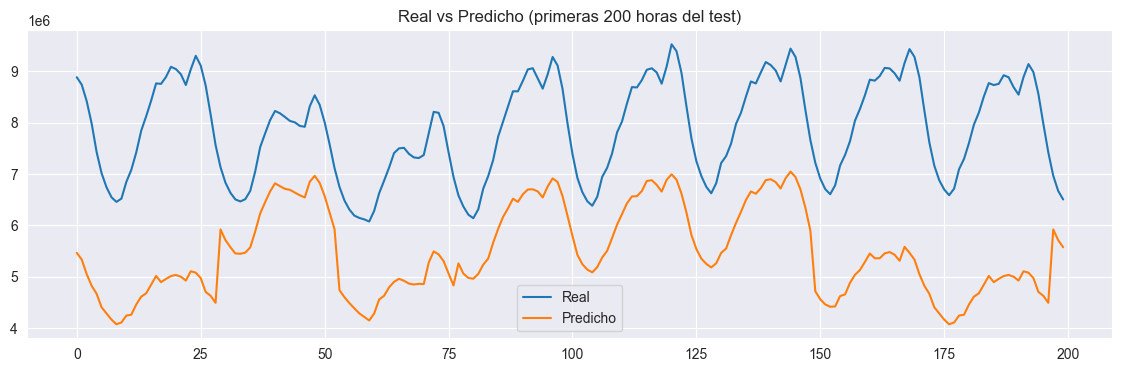

In [27]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Real')
plt.plot(y_pred[:200], label='Predicho')
plt.legend()
plt.title('Real vs Predicho (primeras 200 horas del test)')
plt.show()

El modelo presenta un R^2 negativo, por lo tanto es predice peor que solo usar un promedio.

### 2. Ingeniería de características

### 2.1. Tendencia

El xgboost ahora mismo solo está recibiendo horas cíclicas, sin orden, agregamos una columna de tendencia de modo que sepa en qué momento ocurrió cada observación, así el modelo entenderá que si en 2025(alrededor de tendencia = 14000) sabrá que también hubo un aumento en el tiempo


In [ ]:
data['tendencia'] = np.arange(len(data))

### 2.2 Lag

"El mejor predictor de la demanda ahora mismo, es la demanda de hace poco"

In [16]:
data['lag_1']   = data['Valor'].shift(1)
data['lag_24']  = data['Valor'].shift(24)
data['lag_168'] = data['Valor'].shift(168)

# Eliminar filas con NaN generados por los shifts
data = data.dropna()

X = data.drop(columns='Valor')
y = data['Valor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=0
)

model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.0f} kWh')
print(f'RMSE: {rmse:,.0f} kWh')
print(f'R²:   {r2:.4f}')

MAE:  76,343 kWh
RMSE: 113,253 kWh
R²:   0.9864


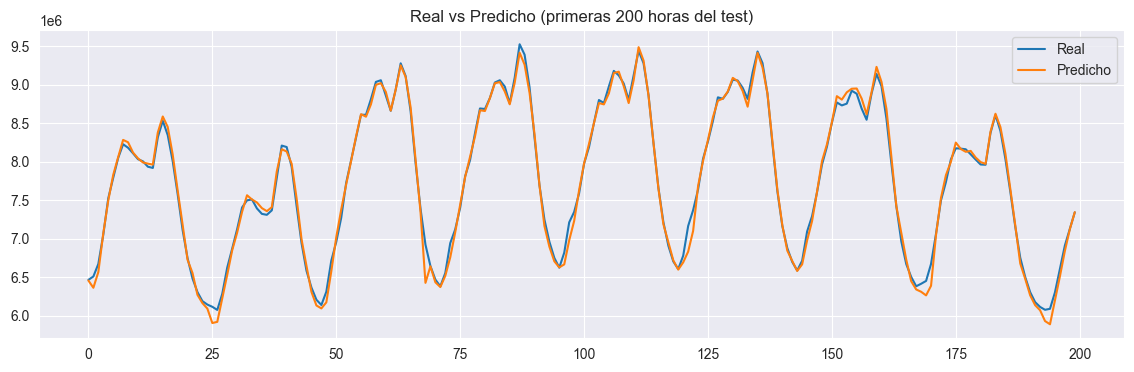

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Real')
plt.plot(y_pred[:200], label='Predicho')
plt.legend()
plt.title('Real vs Predicho (primeras 200 horas del test)')
plt.show()

### **Prophet**

In [3]:
dataProphet = pd.read_csv('../../src/data/raw/preprocesamiento_demanda_colombia_filtrado_agg_hora.csv')

In [8]:
dataProphet = dataProphet.copy().drop(columns = [x for x in dataProphet.columns if x != 'FechaHora' and x!='Valor'  ]).rename(columns = {'FechaHora':'ds','Valor':'y'})

In [5]:
from prophet import Prophet

D:\5_Universidad\ProyectoMetodologiasAgiles\tdsp_template\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

model_prophet.fit(dataProphet)

22:12:02 - cmdstanpy - INFO - Chain [1] start processing
22:12:09 - cmdstanpy - INFO - Chain [1] done processing


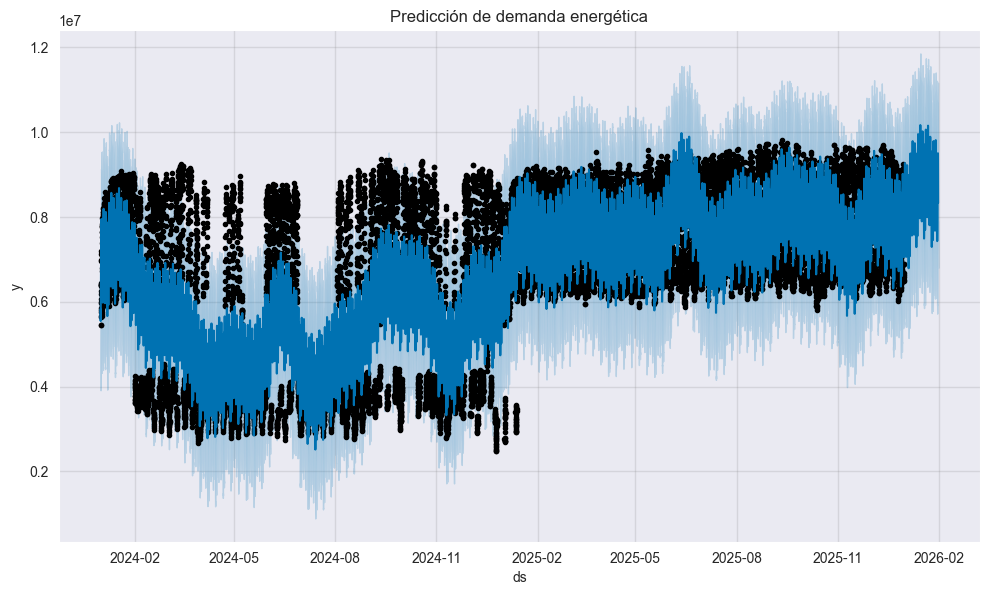

In [10]:
futuro = model_prophet.make_future_dataframe(periods=30*24, freq='h')
forecast = model_prophet.predict(futuro)

model_prophet.plot(forecast)
plt.title('Predicción de demanda energética')
plt.show()

In [11]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model_prophet,
    initial='600 days',
    period='30 days',
    horizon='30 days'
)

df_metrics = performance_metrics(df_cv)
print(df_metrics[['horizon', 'mae', 'rmse', 'mape']].head(10))

  0%|          | 0/4 [00:00<?, ?it/s]22:14:50 - cmdstanpy - INFO - Chain [1] start processing
22:14:54 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:04<00:14,  4.87s/it]22:14:55 - cmdstanpy - INFO - Chain [1] start processing
22:14:59 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:09<00:09,  4.89s/it]22:15:00 - cmdstanpy - INFO - Chain [1] start processing
22:15:04 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:14<00:04,  4.86s/it]22:15:05 - cmdstanpy - INFO - Chain [1] start processing
22:15:13 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:23<00:00,  5.89s/it]


          horizon           mae          rmse      mape
0 3 days 00:00:00  9.885983e+05  1.144970e+06  0.127382
1 3 days 01:00:00  9.908489e+05  1.146097e+06  0.127699
2 3 days 02:00:00  9.929316e+05  1.147413e+06  0.128012
3 3 days 03:00:00  9.943470e+05  1.148844e+06  0.128236
4 3 days 04:00:00  9.952982e+05  1.150586e+06  0.128387
5 3 days 05:00:00  9.979861e+05  1.153642e+06  0.128783
6 3 days 06:00:00  1.002194e+06  1.159532e+06  0.129375
7 3 days 07:00:00  1.007314e+06  1.166105e+06  0.130070
8 3 days 08:00:00  1.013048e+06  1.172762e+06  0.130808
9 3 days 09:00:00  1.018609e+06  1.178856e+06  0.131461
